# CNN & OpenCV Assignment Solutions



## Q1. Load image using PIL

In [8]:
# Import Image class from PIL library
from PIL import Image
from google.colab import files
uploaded = files.upload()

# Get the uploaded file name
image_name = list(uploaded.keys())[0]

# Open the uploaded image
img = Image.open(image_name)

# Print width and height of image
print("Image Size:", img.size)

# Print colour mode (RGB, L, etc.)
print("Colour Mode:", img.mode)


Saving tomato.png to tomato (1).png
Image Size: (859, 726)
Colour Mode: RGBA


## Q2. RGB to NumPy

In [9]:

import numpy as np
# Convert image into NumPy array
image_array = np.array(img)
# Print dimensions of image
print("Image Shape:", image_array.shape)
# Shape means:
# Height x Width x Channels

Image Shape: (726, 859, 4)


## Q3. Normalize grayscale

In [10]:
# Convert image to grayscale
gray_image = img.convert("L")
gray_array = np.array(gray_image)
# Divide every pixel by 255
# This converts pixel values from 0-255 to 0-1
normalized = gray_array / 255.0
# Print min,max pixel value
print("Minimum:", normalized.min())
print("Maximum:", normalized.max())

Minimum: 0.08627450980392157
Maximum: 1.0


## Q4. Reshape for CNN

In [11]:
# Resize image to 128x128
gray_image = gray_image.resize((128,128))
gray_array = np.array(gray_image)
# Normalize pixel
gray_array = gray_array / 255.0
# Reshape image into CNN format
cnn_input = gray_array.reshape(1,128,128,1)
print("CNN Input Shape:", cnn_input.shape) #print new shape

# (Batch Size, Height, Width, Channels)

CNN Input Shape: (1, 128, 128, 1)


## Q5. Pixels calculation

In [12]:
# Total pixels in grayscale image
gray_pixels = 512 * 512
rgb_pixels = 512 * 512 * 3 #rgb has 3 channels
print("Grayscale Pixels =", gray_pixels)
print("RGB Pixel Values =", rgb_pixels)



Grayscale Pixels = 262144
RGB Pixel Values = 786432


## Q6. Random matrix

In [13]:

import numpy as np
# Create random integers between 0 and 255
matrix = np.random.randint(0,256,(5,5))
print(matrix)

# Every value represents a pixel intensity

[[132 121 108 187  86]
 [241 151  45 189   3]
 [122 106  36 249 220]
 [254  62 250 168  58]
 [ 92  40 220 143  91]]


## Q7. Modify pixel

In [14]:

image_array = np.array(img) #convert img to array
print("Original Pixel:", image_array[50,50])
# Change pixel to white
image_array[50,50] = 255
print("Modified Pixel:", image_array[50,50])
# 255 represents white colour

Original Pixel: [255 255 255 255]
Modified Pixel: [255 255 255 255]


## Q8. Display images

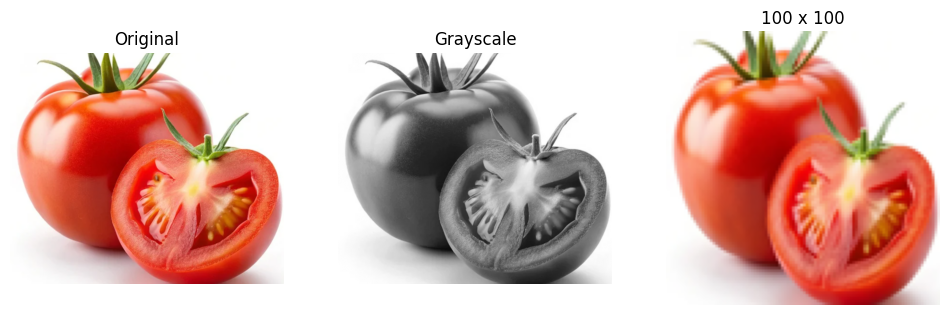

In [15]:

import matplotlib.pyplot as plt
# Convert image to grayscale
gray = img.convert("L")
# Resize image
small = img.resize((100,100))
plt.figure(figsize=(12,4))
# Original Image
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")
# Grayscale Image
plt.subplot(1,3,2)
plt.imshow(gray,cmap="gray")
plt.title("Grayscale")
plt.axis("off")
# Resized Image
plt.subplot(1,3,3)
plt.imshow(small)
plt.title("100 x 100")
plt.axis("off")
plt.show()


## Q9. Histogram

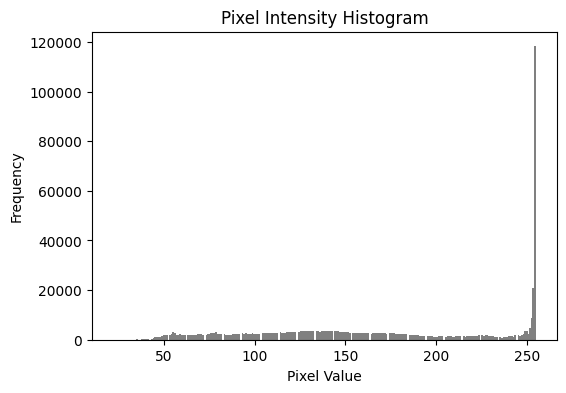

In [16]:
# Convert image into grayscale
gray = img.convert("L")
# Convert to array
gray_array = np.array(gray)
# Plot hist
plt.figure(figsize=(6,4))
plt.hist(gray_array.ravel(),
         bins=256,
         color="gray")
plt.title("Pixel Intensity Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()
#hist shows pixel intensities

## Q10. Resize gray save

Image saved successfully!


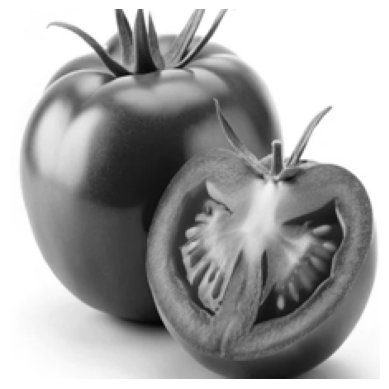

In [17]:
# Resize image to 224x224
resized = img.resize((224,224))
# Convert resized image to grayscale
gray = resized.convert("L")
# Save processed image
gray.save("processed_image.jpg")
print("Image saved successfully!")
plt.imshow(gray,cmap="gray")
plt.axis("off")
plt.show()


## Q11. OpenCV read RGB

Saving strawberry.png to strawberry.png
Image Loaded Successfully!
Shape: (685, 931, 3)
Image Shape: (685, 931, 3)


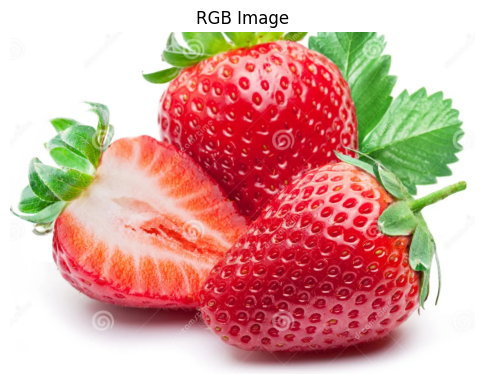

In [21]:


import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

# Upload image
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Read image using OpenCV
cv_img = cv2.imread(image_path)

# Check whether image loaded correctly
if cv_img is None:
    print("Image could not be loaded!")
else:
    print("Image Loaded Successfully!")
    print("Shape:", cv_img.shape)
# Print image shape
print("Image Shape:", cv_img.shape)

# Convert from BGR to RGB
rgb = cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB)

# Display image
plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("RGB Image")
plt.axis("off")
plt.show()

## Q12. Crop center

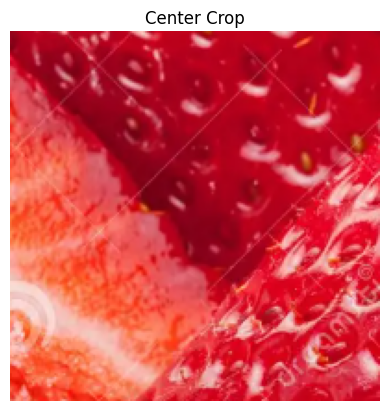

In [22]:
# Get height and width
height, width = cv_img.shape[:2]

# Find image center
center_x = width // 2
center_y = height // 2

# Crop 200x200 image
crop = cv_img[
    center_y-100:center_y+100,
    center_x-100:center_x+100
]

# Display
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.title("Center Crop")
plt.axis("off")
plt.show()

## Q13. Rotate flip

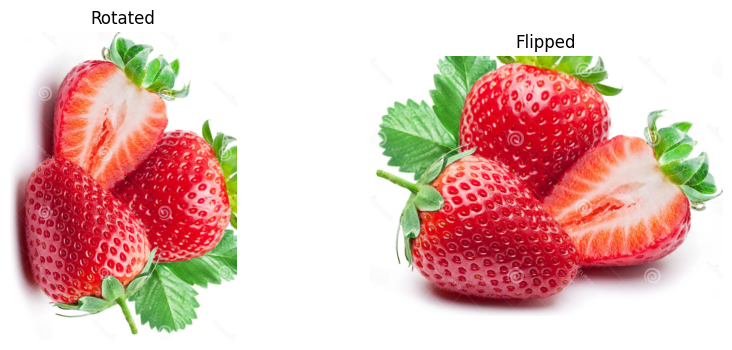

In [23]:
# Rotate image
rotated = cv2.rotate(cv_img, cv2.ROTATE_90_CLOCKWISE)

# Flip image horizontally
flipped = cv2.flip(cv_img, 1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title("Rotated")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB))
plt.title("Flipped")
plt.axis("off")

plt.show()


## Q14. HSV split

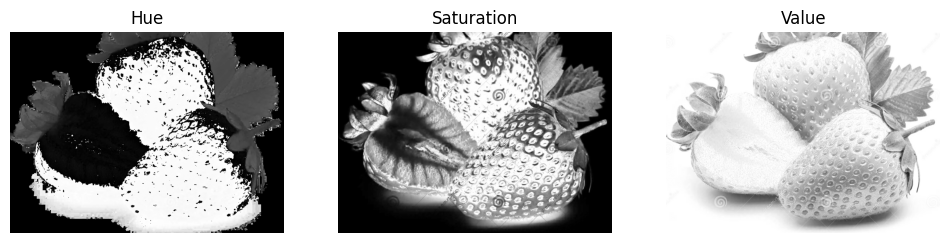

In [24]:
# Convert image to HSV
hsv = cv2.cvtColor(cv_img, cv2.COLOR_BGR2HSV)

# Split channels
H, S, V = cv2.split(hsv)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.show()


## Q15. Rectangle text

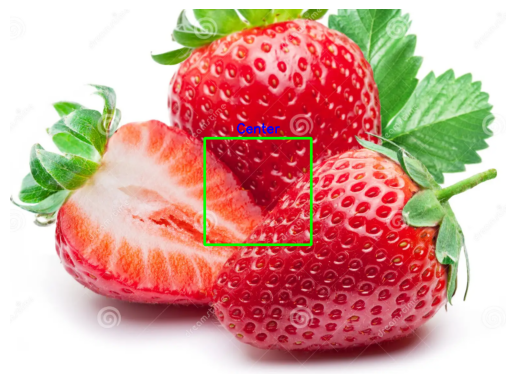

In [25]:
# Make a copy
result = cv_img.copy()

# Get image dimensions
height, width = result.shape[:2]

# Draw rectangle
cv2.rectangle(
    result,
    (width//2-100, height//2-100),
    (width//2+100, height//2+100),
    (0,255,0),
    3
)

# Add text
cv2.putText(
    result,
    "Center",
    (width//2-40, height//2-110),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255,0,0),
    2
)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


## Q16. Blur filters

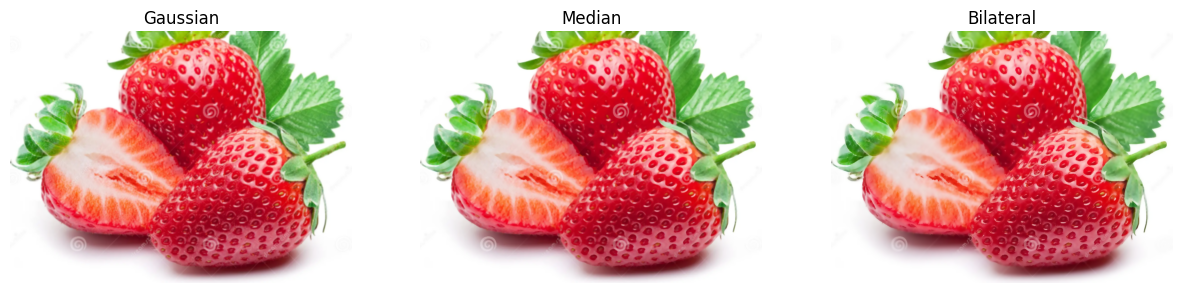

In [26]:
# Gaussian Blur
gaussian = cv2.GaussianBlur(cv_img, (5,5), 0)

# Median Blur
median = cv2.medianBlur(cv_img, 5)

# Bilateral Filter
bilateral = cv2.bilateralFilter(cv_img, 9, 75, 75)

plt.figure(figsize=(15,4))

images = [gaussian, median, bilateral]
titles = ["Gaussian", "Median", "Bilateral"]

for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis("off")

plt.show()


## Q17. Threshold

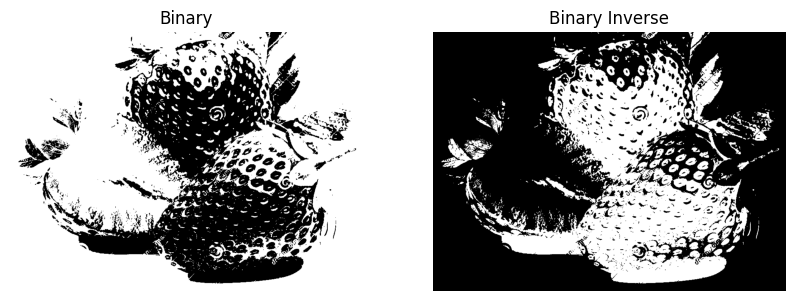

In [27]:
# Convert to grayscale
gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)

# Binary threshold
_, binary = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

# Inverse threshold
_, inverse = cv2.threshold(gray,127,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(binary,cmap="gray")
plt.title("Binary")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(inverse,cmap="gray")
plt.title("Binary Inverse")
plt.axis("off")

plt.show()

## Q18. Canny

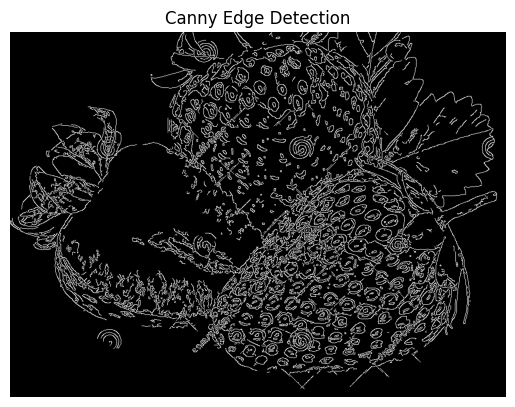

In [28]:
# Convert to grayscale
gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)

# Detect edges
edges = cv2.Canny(gray,100,200)

plt.imshow(edges,cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()


## Q19. Contours

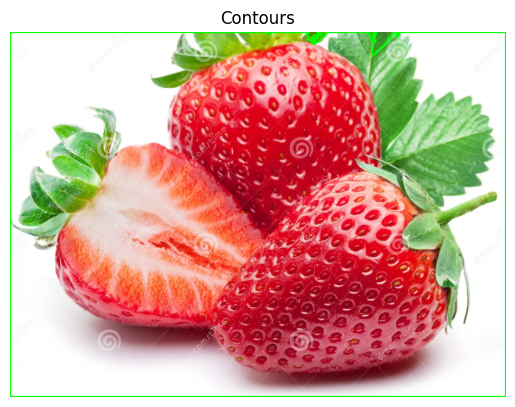

In [29]:
# Convert to grayscale
gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)

# Threshold image
_, thresh = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Draw contours
result = cv_img.copy()

cv2.drawContours(
    result,
    contours,
    -1,
    (0,255,0),
    2
)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Contours")
plt.axis("off")
plt.show()


## Q20. Pipeline

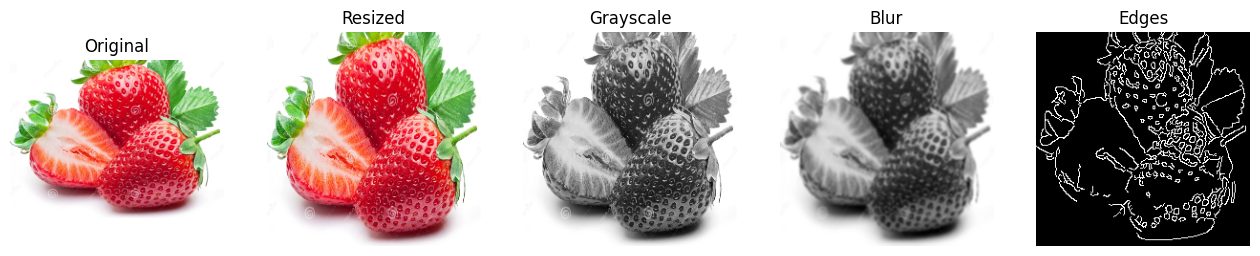

OpenCV Pipeline Completed Successfully!


In [30]:
# Resize the original image to 224 x 224 pixels
resized = cv2.resize(cv_img, (224,224))

# Convert the resized colour image into grayscale
# Grayscale has only one channel (black and white)
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to remove noise from the image
# (5,5) is the kernel size and 0 lets OpenCV calculate sigma automatically
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Detect edges using the Canny Edge Detection algorithm
# Lower Threshold = 100
# Upper Threshold = 200
edges = cv2.Canny(blur, 100, 200)

# Create a figure to display all processing stages
plt.figure(figsize=(16,4))

# List of titles for each output image
titles = [
    "Original",
    "Resized",
    "Grayscale",
    "Blur",
    "Edges"
]

# Store all processed images inside a list
images = [
    # Convert original image from BGR to RGB for correct display
    cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB),
    # Convert resized image from BGR to RGB
    cv2.cvtColor(resized, cv2.COLOR_BGR2RGB),
    # Grayscale image
    gray,
    # Blurred image
    blur,
    edges
]

# Loop through all five images
for i in range(5):

    # Create one subplot for each image
    plt.subplot(1, 5, i+1)

    # First two images are colour images
    if i < 2:

        # Display colour image
        plt.imshow(images[i])

    else:

        # Display grayscale images
        plt.imshow(images[i], cmap="gray")

    # Add title above every image
    plt.title(titles[i])
    plt.axis("off")
plt.show()

print("OpenCV Pipeline Completed Successfully!")


## Q21. Build CNN

In [32]:
# Import TensorFlow Keras libraries
from tensorflow.keras.models import Sequential, load_model

# Import CNN layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import BatchNormalization, Dropout

# Import optimizer
from tensorflow.keras.optimizers import Adam

# Import callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Import NumPy
import numpy as np

# Import Matplotlib
import matplotlib.pyplot as plt# Create a Sequential CNN model
model = Sequential()

# Add first Convolution layer
# 32 filters of size 3x3 with ReLU activation
# Input image size is 224x224 with 3 colour channels
model.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))

# Reduce image size using MaxPooling
model.add(MaxPooling2D((2,2)))

# Add second Convolution layer with 64 filters
model.add(Conv2D(64, (3,3), activation="relu"))

# Reduce feature map size again
model.add(MaxPooling2D((2,2)))

# Convert 2D feature maps into 1D vector
model.add(Flatten())

# Add Fully Connected (Dense) layer
model.add(Dense(128, activation="relu"))

# Output layer with 10 classes using Softmax
model.add(Dense(10, activation="softmax"))

# Display model architecture
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,682 (91.20 MB)

 Trainable params: 23,908,682 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

## Q22. Compile

In [33]:
# Create Adam optimizer with learning rate 0.001
optimizer = Adam(learning_rate=0.001)

# Compile the CNN model
model.compile(

    # Optimizer used for training
    optimizer=optimizer,

    # Loss function for multi-class classification
    loss="categorical_crossentropy",

    # Measure model accuracy
    metrics=["accuracy"]

)


## Q23


In [34]:
# Input Image = 10 × 10

# Filter Size = 3 × 3

# Stride = 1

# Padding = 0

# After Conv2D
# Formula = (Input - Filter) / Stride + 1
# (10 - 3) / 1 + 1 = 8

print("After Conv2D = 8 x 8")

# After MaxPooling (2 × 2)

# 8 / 2 = 4

print("After MaxPooling = 4 x 4")

After Conv2D = 8 x 8
After MaxPooling = 4 x 4


## Q24. BatchNorm Dropout

In [35]:
# Create a new CNN model
model = Sequential()

# Add Convolution layer
model.add(Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)))

# Normalize feature maps
model.add(BatchNormalization())

# Reduce image size
model.add(MaxPooling2D((2,2)))

# Convert feature maps into vector
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128,activation="relu"))

# Randomly drop 50% neurons
# Helps reduce overfitting
model.add(Dropout(0.5))

# Output layer
model.add(Dense(10,activation="softmax"))


## Q25. Train

In [39]:
# Import NumPy
import numpy as np

# Create dummy training images
X_train = np.random.rand(100, 224, 224, 3)

# Create dummy training labels (10 classes)
y_train = np.eye(10)[np.random.randint(0, 10, 100)]

# Create dummy testing images
X_test = np.random.rand(20, 224, 224, 3)

# Create dummy testing labels (10 classes)
y_test = np.eye(10)[np.random.randint(0, 10, 20)]
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
# Create EarlyStopping callback
early_stop = EarlyStopping(

    # Monitor validation loss
    monitor="val_loss",

    # Stop training after 3 epochs without improvement
    patience=3

)

# Train the model
history = model.fit(

    # Training images
    X_train,

    # Training labels
    y_train,

    # Number of training cycles
    epochs=15,

    # Images processed at one time
    batch_size=32,

    # Validation dataset
    validation_data=(X_test, y_test),

    # Apply EarlyStopping
    callbacks=[early_stop]

)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.1600 - loss: 173.5527 - val_accuracy: 0.2000 - val_loss: 36.8401
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.1700 - loss: 174.1868 - val_accuracy: 0.1000 - val_loss: 24.1814
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.3200 - loss: 40.5353 - val_accuracy: 0.2000 - val_loss: 16.8623
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.2600 - loss: 15.0807 - val_accuracy: 0.2000 - val_loss: 6.7741
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.2500 - loss: 5.5154 - val_accuracy: 0.2000 - val_loss: 3.9503
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.1300 - loss: 2.5427 - val_accuracy: 0.2000 - val_loss: 3.2688
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.1600 - loss: 2.7822 - val_accuracy: 0.2000 - val_loss: 2.7012
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.1900 - loss: 2.3782 - val_accuracy: 0.2000 - val_loss: 2.2971

## Q26. Accuracy plot

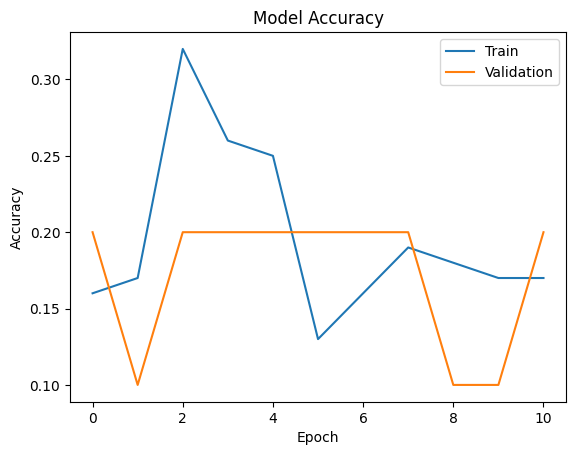

In [40]:
# Plot training accuracy
plt.plot(history.history["accuracy"])

# Plot validation accuracy
plt.plot(history.history["val_accuracy"])

# Add graph title
plt.title("Model Accuracy")

# Label x-axis
plt.xlabel("Epoch")

# Label y-axis
plt.ylabel("Accuracy")

# Add legend
plt.legend(["Train","Validation"])

# Display graph
plt.show()

## Q27. Save load

In [41]:
# Save trained model
model.save("cnn_model.h5")

# Load saved model
new_model = load_model("cnn_model.h5")


## Q28. Predict one image

In [45]:
# Import required libraries
from PIL import Image
import numpy as np
from google.colab import files

# Upload image
uploaded = files.upload()

# Get image name
filename = list(uploaded.keys())[0]

# Open image
image = Image.open(filename)

# Convert image to RGB (3 channels)
image = image.convert("RGB")

# Resize image
img = image.resize((224,224))

# Convert image into NumPy array
img = np.array(img)

# Normalize pixel values
img = img / 255.0

# Print image shape
print("Image Shape:", img.shape)

# Reshape for CNN
img = img.reshape(1,224,224,3)

# Predict image
prediction = model.predict(img)

# Get predicted class
predicted_class = np.argmax(prediction)

# Print result
print("Predicted Class:", predicted_class)

Saving strawberry.png to strawberry (2).png
Image Shape: (224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Predicted Class: 6


## Q29. Confusion matrix

In [46]:
# Import evaluation functions
from sklearn.metrics import confusion_matrix, classification_report

# Predict test dataset
y_pred = model.predict(X_test)

# Convert probabilities into class labels
y_pred = np.argmax(y_pred, axis=1)

# Convert actual labels into class labels
y_true = np.argmax(y_test, axis=1)

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Print Confusion Matrix
print(cm)

# Print Classification Report
print(classification_report(y_true, y_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step
[[0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 4 0 0 0]
 [0 0 0 0 0 0 4 0 0 0]
 [0 0 0 0 0 0 4 0 0 0]
 [0 0 0 0 0 0 2 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         4
           6       0.20      1.00      0.33         4
           7       0.00      0.00      0.00         4
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         1

    accuracy                           0.20        20
   macro avg       0.02      0.10      0.03        20
weighted avg       0.04   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Q30. Complete pipeline

In [47]:
# Steps:
# 1. Build model
# 2. Compile model
# 3. Train using EarlyStopping + ModelCheckpoint
# 4. Evaluate
# 5. Confusion Matrix
# 6. Predict new image
# Create CNN model
model = Sequential()

# First Convolution layer
model.add(Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)))

# First MaxPooling layer
model.add(MaxPooling2D((2,2)))

# Second Convolution layer
model.add(Conv2D(64,(3,3),activation="relu"))

# Second MaxPooling layer
model.add(MaxPooling2D((2,2)))

# Convert feature maps into vector
model.add(Flatten())

# Hidden Dense layer
model.add(Dense(128,activation="relu"))

# Output layer
model.add(Dense(10,activation="softmax"))

# Compile model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Create EarlyStopping callback
early_stop = EarlyStopping(monitor="val_loss", patience=3)

# Save the best model during training
checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

# Evaluate model performance
loss, accuracy = model.evaluate(X_test, y_test)

# Print accuracy
print("Accuracy:", accuracy)

# Predict test dataset
y_pred = model.predict(X_test)

# Convert predictions into class labels
y_pred = np.argmax(y_pred, axis=1)

# Convert true labels into class labels
y_true = np.argmax(y_test, axis=1)

# Print Confusion Matrix
print(confusion_matrix(y_true, y_pred))

# Print Classification Report
print(classification_report(y_true, y_pred))

# Resize input image
img = image.resize((224,224))

# Convert image into NumPy array and normalize
img = np.array(img) / 255.0

# Reshape image for CNN
img = img.reshape(1,224,224,3)

# Predict image class
prediction = model.predict(img)

# Print predicted class
print("Predicted Class:", np.argmax(prediction))









/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1121 - loss: 21.9035

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.1100 - loss: 28.5413 - val_accuracy: 0.0500 - val_loss: 8.3704
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1289 - loss: 6.3487

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.1300 - loss: 5.1897 - val_accuracy: 0.0500 - val_loss: 2.7865
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2022 - loss: 2.5673

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.2100 - loss: 2.5469 - val_accuracy: 0.2000 - val_loss: 2.3093
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0812 - loss: 2.2805

4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.0800 - loss: 2.2622 - val_accuracy: 0.0500 - val_loss: 2.3020
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2800 - loss: 2.1283 - val_accuracy: 0.2000 - val_loss: 2.4368
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2100 - loss: 2.0982 - val_accuracy: 0.1500 - val_loss: 2.3213
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7900 - loss: 1.9553 - val_accuracy: 0.0500 - val_loss: 2.3730
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.0500 - loss: 2.3730
Accuracy: 0.05000000074505806
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
[[0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 4 0 0 0 0 0 0 0 0]
 [0 4 0 0 0 0 0 0 0 0]
 [0 4 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.05      1.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
